# Factor-Based Return & Volatility Analysis on NIFTY 50

**Objective**: 
To analyze equity return behavior, volatility patterns, and simple factor characteristics
(momentum and volatility) for major Indian stocks across multiple market regimes.

**Time Period:** 2018–2024  
**Data Source:** Yahoo Finance (yfinance)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
stocks = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS", "HDFCBANK.NS",
    "ICICIBANK.NS", "HINDUNILVR.NS", "ITC.NS",
    "LT.NS", "SBIN.NS", "AXISBANK.NS"
]


In [4]:
data = yf.download(
    stocks,
    start="2018-01-01",
    end="2024-01-01"
)

data.columns


[*********************100%***********************]  10 of 10 completed


MultiIndex([( 'Close',   'AXISBANK.NS'),
            ( 'Close',   'HDFCBANK.NS'),
            ( 'Close', 'HINDUNILVR.NS'),
            ( 'Close',  'ICICIBANK.NS'),
            ( 'Close',       'INFY.NS'),
            ( 'Close',        'ITC.NS'),
            ( 'Close',         'LT.NS'),
            ( 'Close',   'RELIANCE.NS'),
            ( 'Close',       'SBIN.NS'),
            ( 'Close',        'TCS.NS'),
            (  'High',   'AXISBANK.NS'),
            (  'High',   'HDFCBANK.NS'),
            (  'High', 'HINDUNILVR.NS'),
            (  'High',  'ICICIBANK.NS'),
            (  'High',       'INFY.NS'),
            (  'High',        'ITC.NS'),
            (  'High',         'LT.NS'),
            (  'High',   'RELIANCE.NS'),
            (  'High',       'SBIN.NS'),
            (  'High',        'TCS.NS'),
            (   'Low',   'AXISBANK.NS'),
            (   'Low',   'HDFCBANK.NS'),
            (   'Low', 'HINDUNILVR.NS'),
            (   'Low',  'ICICIBANK.NS'),
            (   

In [5]:
prices = data["Close"]

In [6]:
data.columns


MultiIndex([( 'Close',   'AXISBANK.NS'),
            ( 'Close',   'HDFCBANK.NS'),
            ( 'Close', 'HINDUNILVR.NS'),
            ( 'Close',  'ICICIBANK.NS'),
            ( 'Close',       'INFY.NS'),
            ( 'Close',        'ITC.NS'),
            ( 'Close',         'LT.NS'),
            ( 'Close',   'RELIANCE.NS'),
            ( 'Close',       'SBIN.NS'),
            ( 'Close',        'TCS.NS'),
            (  'High',   'AXISBANK.NS'),
            (  'High',   'HDFCBANK.NS'),
            (  'High', 'HINDUNILVR.NS'),
            (  'High',  'ICICIBANK.NS'),
            (  'High',       'INFY.NS'),
            (  'High',        'ITC.NS'),
            (  'High',         'LT.NS'),
            (  'High',   'RELIANCE.NS'),
            (  'High',       'SBIN.NS'),
            (  'High',        'TCS.NS'),
            (   'Low',   'AXISBANK.NS'),
            (   'Low',   'HDFCBANK.NS'),
            (   'Low', 'HINDUNILVR.NS'),
            (   'Low',  'ICICIBANK.NS'),
            (   

In [7]:
prices = prices.dropna()
prices.shape
prices.tail()

Ticker,AXISBANK.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2023-12-22,1086.532227,813.178833,2475.709961,978.264954,1471.446655,401.367279,3418.937500,1273.102173,613.920776,3561.377197
2023-12-26,1092.472534,818.824402,2484.504883,979.052002,1453.605591,402.469482,3430.832275,1279.554443,615.174133,3534.881348
2023-12-27,1104.552856,828.971863,2507.141602,986.086792,1475.400879,403.042603,3483.866699,1283.922119,625.297729,3549.456055
2023-12-28,1106.050293,829.920837,2531.652588,989.677917,1471.211304,409.214783,3458.356934,1293.203369,628.045532,3538.932373
2023-12-29,1100.509399,831.867615,2560.633301,980.527893,1452.617065,407.451263,3466.172119,1282.979126,619.030762,3532.878174


In [9]:
returns = prices.pct_change().dropna()
returns.head()


Ticker,AXISBANK.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2018-01-02,-0.010610,0.009625,-0.004388,-0.001934,-0.003725,-0.005909,-0.008686,0.001539,-0.012537,-0.005443
2018-01-03,0.001698,-0.010521,0.008777,0.017113,-0.008158,0.001534,0.020444,0.004006,-0.001319,0.002831
2018-01-04,-0.000981,0.003913,0.001407,-0.000952,-0.005777,0.001532,0.031679,0.006012,0.018656,0.006992
2018-01-05,0.005983,0.001989,0.003180,-0.005720,-0.003349,0.005162,-0.000608,0.003205,-0.006969,0.012081
2018-01-08,0.003906,-0.001610,0.008735,0.003995,0.023765,0.010270,0.017758,0.005741,-0.001795,0.009371


## Return Calculation

Daily log returns were approximated using percentage change
to analyze short-term price behavior and volatility dynamics.


In [10]:
rolling_vol_20 = returns.rolling(window=20).std()


In [11]:
rolling_vol_20 = returns.rolling(window=20).std()
rolling_vol_20.head()


Ticker,AXISBANK.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2018-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


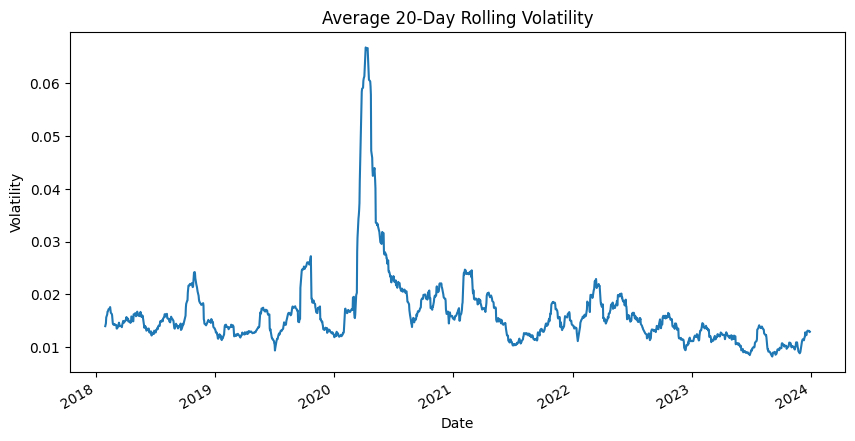

In [12]:
rolling_vol_20.mean(axis=1).plot()
plt.title("Average 20-Day Rolling Volatility")
plt.ylabel("Volatility")
plt.show()


In [13]:
momentum_3m = prices.pct_change(periods=60)
momentum_3m.tail()


Ticker,AXISBANK.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,LT.NS,RELIANCE.NS,SBIN.NS,TCS.NS
Date,,,,,,,,,,
2023-12-22,0.068060,0.091346,0.047919,0.039682,0.073927,0.028468,0.198260,0.095964,0.071880,0.071773
2023-12-26,0.078982,0.094170,0.050327,0.048909,0.070711,0.031642,0.198280,0.100555,0.073435,0.061263
2023-12-27,0.079155,0.115565,0.050237,0.062719,0.082061,0.017700,0.195258,0.092005,0.099703,0.064570
2023-12-28,0.074643,0.119151,0.078349,0.067155,0.099640,0.052978,0.168787,0.116297,0.104161,0.077184
2023-12-29,0.063278,0.119865,0.088371,0.046959,0.088767,0.039829,0.166179,0.102324,0.072676,0.077825


In [14]:
latest_momentum = momentum_3m.iloc[-1].sort_values(ascending=False)
latest_momentum


Ticker
LT.NS            0.166179
HDFCBANK.NS      0.119865
RELIANCE.NS      0.102324
INFY.NS          0.088767
HINDUNILVR.NS    0.088371
TCS.NS           0.077825
SBIN.NS          0.072676
AXISBANK.NS      0.063278
ICICIBANK.NS     0.046959
ITC.NS           0.039829
Name: 2023-12-29 00:00:00, dtype: float64

## Momentum Factor

Stocks were ranked based on 3-month returns to observe persistence
in price movements, a commonly studied market factor.


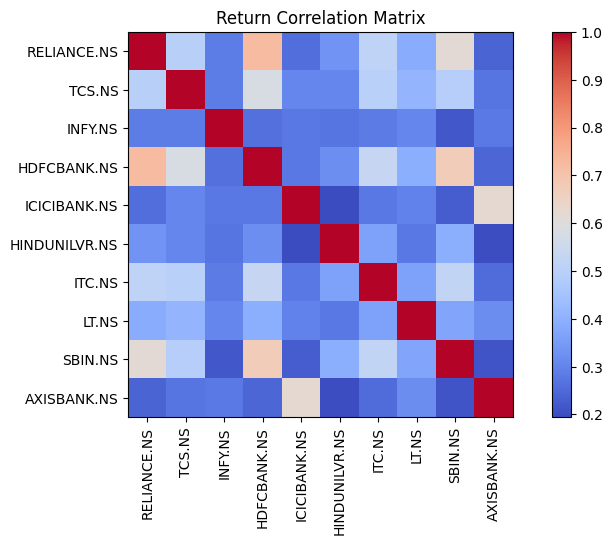

In [15]:
corr_matrix = returns.corr()

plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(stocks)), stocks, rotation=90)
plt.yticks(range(len(stocks)), stocks)
plt.title("Return Correlation Matrix")
plt.show()


## Key Observations

- Volatility spikes were observed during high-uncertainty periods,
  indicating regime-dependent risk behavior.
- High-momentum stocks often exhibited higher short-term volatility,
  highlighting a risk-return tradeoff.
- Correlations across stocks increased during market stress,
  reducing diversification benefits.


## Limitations & Future Scope

- No transaction costs or liquidity constraints considered.
- Analysis is descriptive; no backtesting of trading strategies.
- Future work could include return forecasting, factor backtesting,
  and risk-adjusted performance metrics.


## Summary

This project analyzes equity return behavior and volatility patterns
for major Indian stocks across multiple market regimes (2018–2024).

The focus is on:
- Understanding return distributions
- Studying volatility clustering
- Observing simple factor characteristics (momentum, volatility)
- Interpreting correlation behavior during market stress

The analysis emphasizes interpretability, data quality,
and investment relevance over predictive complexity.
